In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.gridspec as gridspec
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, KFold, cross_val_score, cross_val_predict

In [2]:
# Load file
df = pd.read_excel("Co2_data.xlsx")

# Drop unnecessary metadata columns
df = df.drop(columns=["Country Name", "Country Code", "Series Code"], errors="ignore")

# Transpose FIRST
df = df.set_index("Series Name").T
df = df.rename_axis(None, axis=0)

# Reset index so Year becomes column
df = df.reset_index()

# Rename year column
df = df.rename(columns={"index": "Year"})

# Extract numeric year
df["Year"] = df["Year"].str.extract(r"(\d{4})").astype(int)

df.head()

Series Name,Year,Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),GDP per capita (current US$),Energy use (kg of oil equivalent per capita),Renewable energy consumption (% of total final energy consumption),"Industry (including construction), value added (% of GDP)",Urban population (% of total population),Population growth (annual %)
0,1976,75.2026,556.389688,..,..,..,24.423621,2.871435
1,1977,66.4674,535.965308,..,..,..,25.160071,2.983907
2,1978,69.5374,526.895853,..,..,..,25.904516,3.063984
3,1979,99.4213,660.994041,..,..,..,26.656201,3.084517
4,1980,89.6006,870.359935,..,..,..,27.414371,3.120664


In [3]:
df.columns.name = None

# Rename the long columns
df = df.rename(columns={
    "Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)": "CO2",
    "GDP per capita (current US$)": "GDP_pc",
    "Energy use (kg of oil equivalent per capita)": "Energy",
    "Renewable energy consumption (% of total final energy consumption)": "Renewable",
    "Industry (including construction), value added (% of GDP)": "Industry",
    "Urban population (% of total population)": "Urban",
    "Population growth (annual %)": "PopGrowth"
})

# Replace the nan strings with NAN
df = df.replace("..", np.nan)

# Print the dataframe
df.head()

/tmp/ipython-input-186/291539728.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("..", np.nan)


,Year,CO2,GDP_pc,Energy,Renewable,Industry,Urban,PopGrowth
0,1976,75.2026,556.389688,NaN,NaN,NaN,24.423621,2.871435
1,1977,66.4674,535.965308,NaN,NaN,NaN,25.160071,2.983907
2,1978,69.5374,526.895853,NaN,NaN,NaN,25.904516,3.063984
3,1979,99.4213,660.994041,NaN,NaN,NaN,26.656201,3.084517
4,1980,89.6006,870.359935,NaN,NaN,NaN,27.414371,3.120664


In [4]:
# Check for missing values
df.isna().sum().sort_values(ascending=False)

,0
Renewable,18
Energy,17
Industry,6
CO2,1
Urban,1
GDP_pc,1
PopGrowth,1
Year,0


In [5]:
# Check the missing values by years
df_missing_years = df.copy()
df_missing_years["Missing_Count"] = df_missing_years.isna().sum(axis=1)

df_missing_years = df_missing_years[["Year", "Missing_Count"]].sort_values("Year")

df_missing_years

,Year,Missing_Count
0,1976,3
1,1977,3
2,1978,3
3,1979,3
4,1980,3
5,1981,2
6,1982,2
7,1983,2
8,1984,2
9,1985,2


In [6]:
# Missing features by year
missing_features_per_year = {}

for year in df["Year"].unique():
    row = df[df["Year"] == year]

    if not row.empty:
        missing_cols = row.columns[row.isna().iloc[0]]
        missing_features_per_year[year] = list(missing_cols)

missing_features_per_year

{np.int64(1976): ['Energy', 'Renewable', 'Industry'],
 np.int64(1977): ['Energy', 'Renewable', 'Industry'],
 np.int64(1978): ['Energy', 'Renewable', 'Industry'],
 np.int64(1979): ['Energy', 'Renewable', 'Industry'],
 np.int64(1980): ['Energy', 'Renewable', 'Industry'],
 np.int64(1981): ['Energy', 'Renewable'],
 np.int64(1982): ['Energy', 'Renewable'],
 np.int64(1983): ['Energy', 'Renewable'],
 np.int64(1984): ['Energy', 'Renewable'],
 np.int64(1985): ['Energy', 'Renewable'],
 np.int64(1986): ['Energy', 'Renewable'],
 np.int64(1987): ['Energy', 'Renewable'],
 np.int64(1988): ['Energy', 'Renewable'],
 np.int64(1989): ['Energy', 'Renewable'],
 np.int64(1990): [],
 np.int64(1991): [],
 np.int64(1992): [],
 np.int64(1993): [],
 np.int64(1994): [],
 np.int64(1995): [],
 np.int64(1996): [],
 np.int64(1997): [],
 np.int64(1998): [],
 np.int64(1999): [],
 np.int64(2000): [],
 np.int64(2001): [],
 np.int64(2002): [],
 np.int64(2003): [],
 np.int64(2004): [],
 np.int64(2005): [],
 np.int64(2006):

In [7]:
# Filter the dataset to stop at 2023 since 2024 and 2025 are missing
df_filtered = df[(df["Year"] >= 1990) & (df["Year"] <= 2023)]
df_filtered

,Year,CO2,GDP_pc,Energy,Renewable,Industry,Urban,PopGrowth
14,1990,75.1111,556.376449,287.479974,87.8,35.410327,35.186618,2.702888
15,1991,81.3463,596.938796,298.657962,86.5,36.965566,35.965763,2.641103
16,1992,89.1060,508.515906,307.485765,84.5,37.709608,36.745643,2.625288
17,1993,86.6517,539.573202,299.654136,86.3,33.174342,37.533576,2.650148
18,1994,80.8977,744.884247,263.018632,88.6,31.318390,38.330657,2.641357
19,1995,88.8531,1271.616174,256.918214,88.0,36.540490,39.136410,2.636629
20,1996,103.6329,1632.724694,268.073151,87.1,37.445479,39.950356,2.614297
21,1997,100.8221,1720.275409,278.489227,85.6,35.248850,40.772017,2.603087
22,1998,91.3518,1822.469985,269.365011,87.2,28.702440,41.600914,2.613376
23,1999,89.9873,480.669364,272.180193,87.2,29.363693,42.436570,2.635929


In [8]:
#Fill missing values for 2023 with interpolation to keep the trend
df_filtered = df_filtered.sort_values("Year")

df_filtered = df_filtered.interpolate(method="linear", limit_direction="forward", axis=0)
df_filtered.isna().sum()

,0
Year,0
CO2,0
GDP_pc,0
Energy,0
Renewable,0
Industry,0
Urban,0
PopGrowth,0


In [9]:
print(df_filtered.describe())

              Year         CO2       GDP_pc      Energy  Renewable   Industry  \
count    34.000000   34.000000    34.000000   34.000000  34.000000  34.000000   
mean   2006.500000  103.026344  1695.441620  303.950791  84.241176  27.029985   
std       9.958246   15.951096   881.575430   30.820184   2.767464   6.039082   
min    1990.000000   75.111100   480.669364  256.918214  79.900000  18.173132   
25%    1998.250000   90.328425   749.510372  282.010601  81.450000  22.496547   
50%    2006.500000  102.612700  1818.006657  299.156049  84.500000  25.877025   
75%    2014.750000  117.850375  2364.374060  330.620578  86.450000  30.829715   
max    2023.000000  130.900500  3189.812865  376.069865  88.600000  37.709608   

           Urban  PopGrowth  
count  34.000000  34.000000  
mean   48.701430   2.587953  
std     8.208076   0.224628  
min    35.186618   2.092817  
25%    41.809828   2.552902  
50%    48.830035   2.641786  
75%    55.530237   2.760119  
max    62.174676   2.802785  


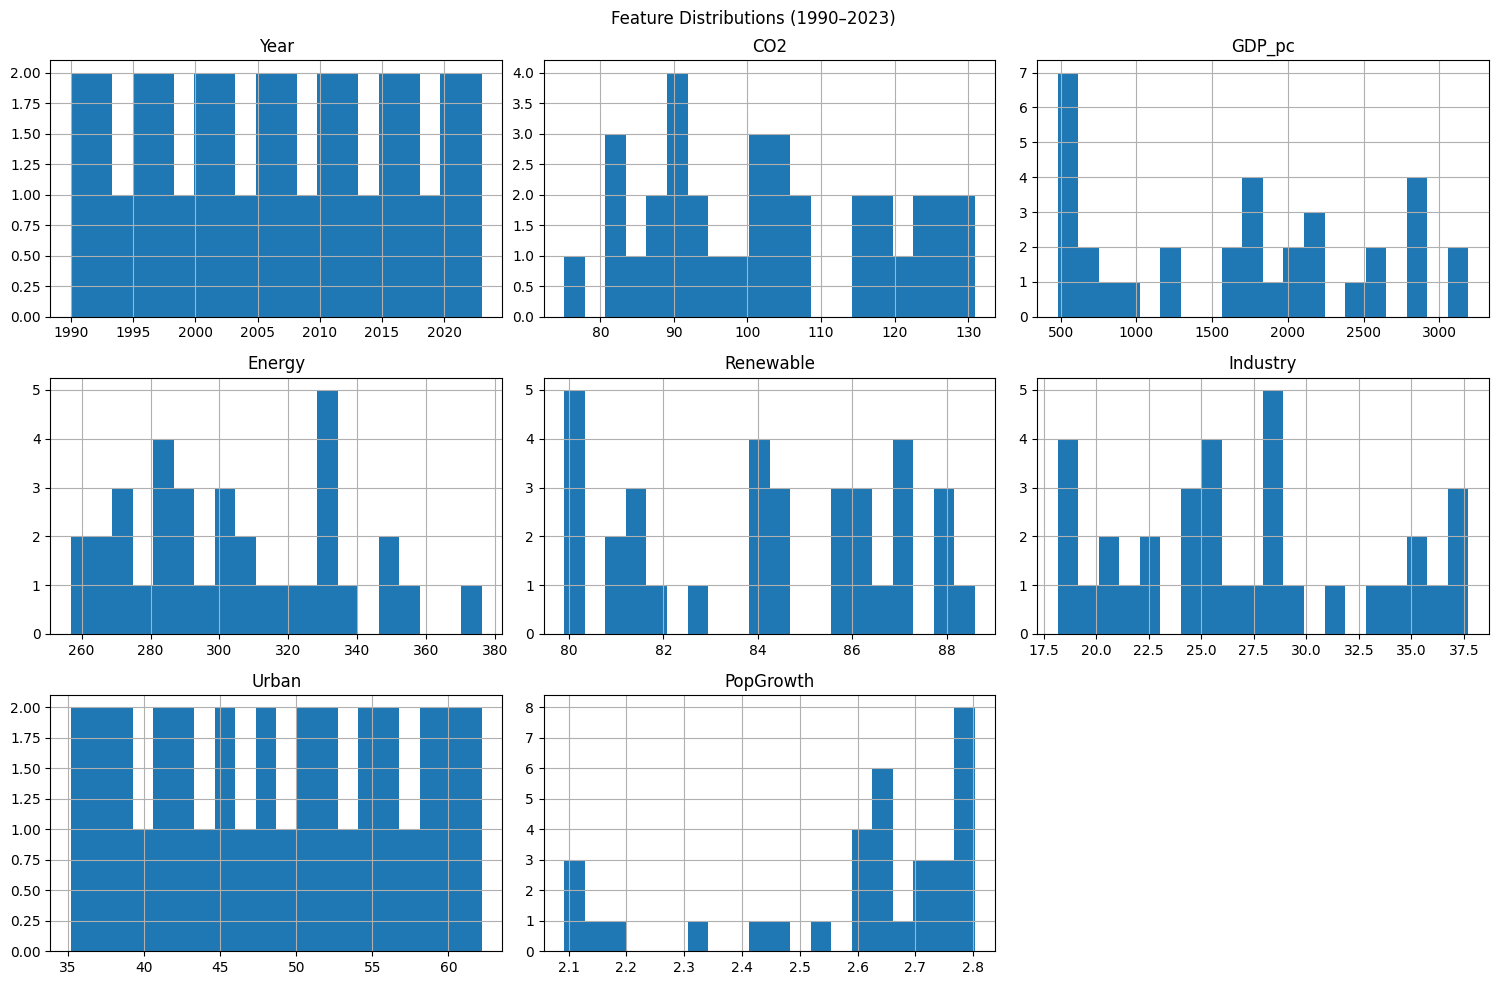

In [10]:
# Plot the histogram to visualize distribution
df_filtered.hist(figsize=(15,10), bins=20)
plt.suptitle("Feature Distributions (1990–2023)")
plt.tight_layout()
plt.show()


## Takeaways from the distribution
*   No missing years as expected.
*   CO2 emissions looks roughly multimodal and slightly skewed which could mean emissions increased in phases over time (structural shifts likely occured).
*   GDP per capita shows very clear right skew with most values clustered around lower GDP and Few large spikes. Log transformation could improve baseline performance.
*   Renewable energy consumption is spread across 80–90 with no strong central tendency.
*   Urban population is fairly uniformly distributed which could indicator a good predictor. The distribution looks similar to year
*   Annual population growth is concentrated around two points. It also looks left-skewed. Low variance means it may or may not contribute less.







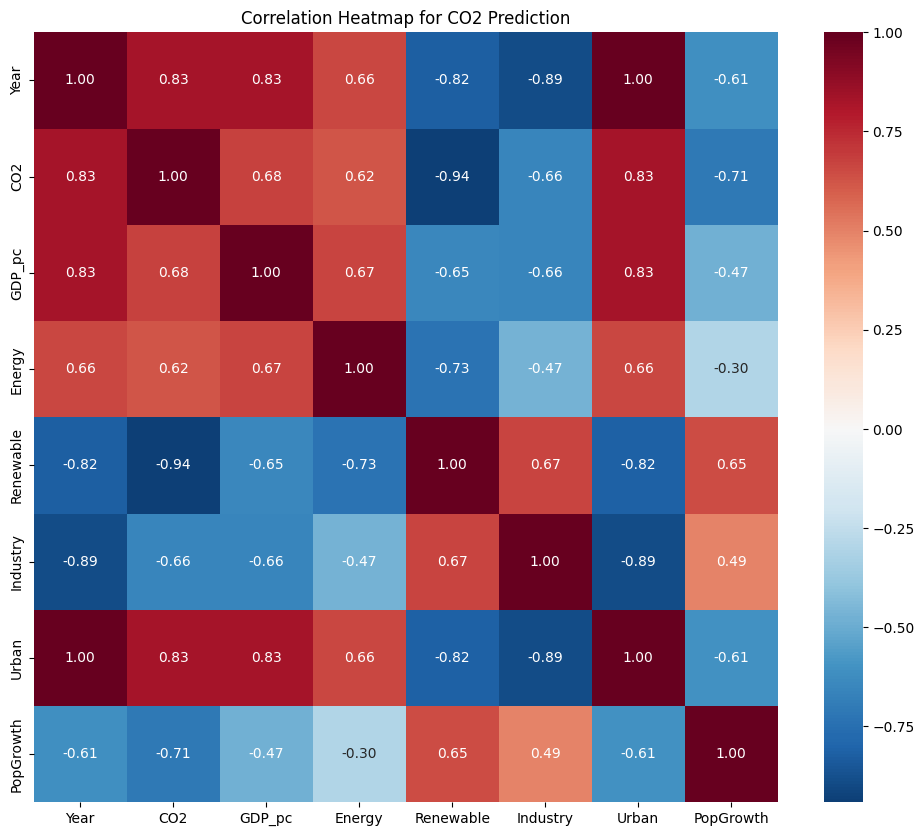

In [11]:
# Calculate the correlation matrix
corr_matrix = df_filtered.corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")

# Labeling
plt.title('Correlation Heatmap for CO2 Prediction')
plt.show()




*   Year and Urban looked similar in the distribution, the correlation plot confirms it as they are highly correlated.
*   Renewable energy is potentially highly important
*   multicollinearity exists, ridge regression and tree models will be used instead and compared
*   Industry's negative correlation with CO2 is counterintuitive which requires further investigation








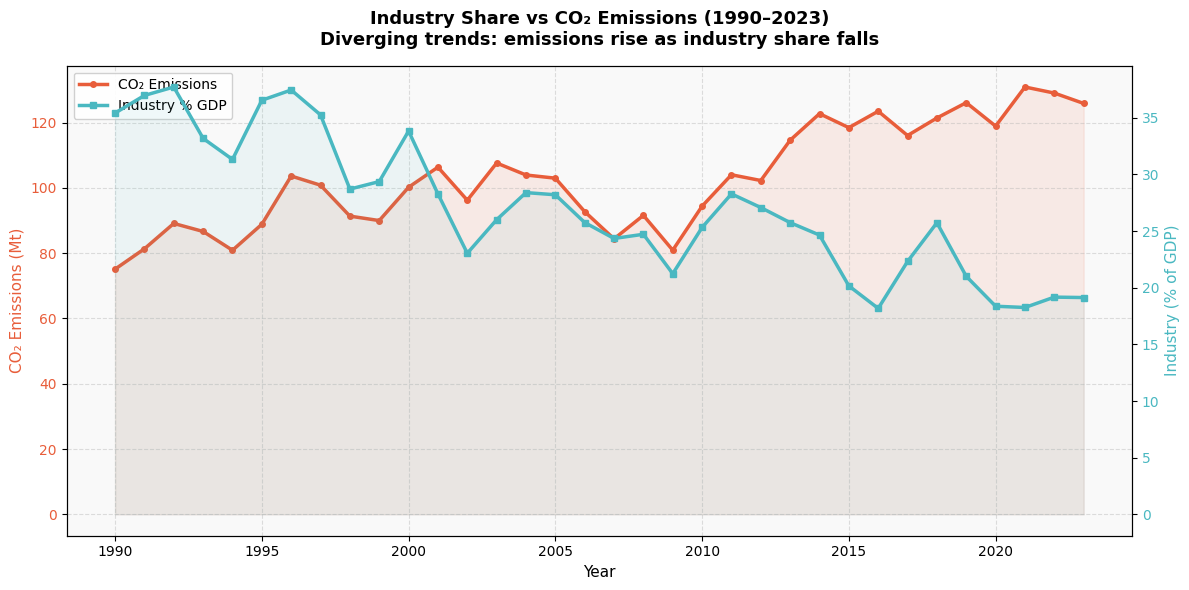

In [12]:
# Plot industry and CO2 to investigae
years = df_filtered['Year'].tolist()
co2 = df_filtered['CO2'].tolist()
industry = df_filtered['Industry'].tolist()

fig, ax1 = plt.subplots(figsize=(12, 6))

# CO2 on left axis
color_co2 = '#e85d3a'
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('CO₂ Emissions (Mt)', color=color_co2, fontsize=11)
ax1.plot(years, co2, color=color_co2, linewidth=2.5, marker='o', markersize=4, label='CO₂ Emissions')
ax1.fill_between(years, co2, alpha=0.1, color=color_co2)
ax1.tick_params(axis='y', labelcolor=color_co2)

# Industry on right axis
ax2 = ax1.twinx()
color_ind = '#4ab8c1'
ax2.set_ylabel('Industry (% of GDP)', color=color_ind, fontsize=11)
ax2.plot(years, industry, color=color_ind, linewidth=2.5, marker='s', markersize=4, label='Industry % GDP')
ax2.fill_between(years, industry, alpha=0.08, color=color_ind)
ax2.tick_params(axis='y', labelcolor=color_ind)

# Styling
ax1.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('white')
ax1.grid(True, linestyle='--', alpha=0.4)
plt.title('Industry Share vs CO₂ Emissions (1990–2023)\nDiverging trends: emissions rise as industry share falls',
          fontsize=13, fontweight='bold', pad=15)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig('industry_co2.png', dpi=150, bbox_inches='tight')
plt.show()

Industry has been declining over time (from ~37% in 1990 down to ~18% by 2023), while CO2 has been rising over the same period. So the negative correlation is purely a time trend artifact — it doesn't mean industry causes lower emissions. It just means both variables are trending in opposite directions over time.

In [13]:
# Feature Selection & Transformation
# We drop 'Year' because it is perfectly redundant with 'Urban'
features = ['GDP_pc', 'Energy', 'Renewable', 'Industry', 'Urban', 'PopGrowth']
X = df_filtered[features].copy()
y = df_filtered['CO2']

# Apply Log Transformation to GDP_pc to handle its heavy right-skewness
X['GDP_pc'] = np.log1p(X['GDP_pc'])

# Use Leave-One-Out CV instead of a single train/test split due to dataset size
loo = LeaveOneOut()

model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,          # shallow — prevents overfitting on small data
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

# MAE via LOO (Using LOO due to the dataset size)
mae_scores = cross_val_score(model, X, y, cv=loo, scoring='neg_mean_absolute_error')
print(f"LOO MAE: {(-mae_scores).mean():.4f} ± {(-mae_scores).std():.4f}")

# R² via KFold (needs >1 sample per fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
print(f"KFold R²:  {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

LOO MAE: 4.2877 ± 3.6068
KFold R²:  0.7718 ± 0.1587


── Ridge Regression ──────────────────────
LOO MAE: 4.2696 ± 3.5510
KFold R²: 0.8121 ± 0.0914

── XGBoost ───────────────────────────────
LOO MAE: 4.2877 ± 3.6068
KFold R²: 0.7718 ± 0.1587


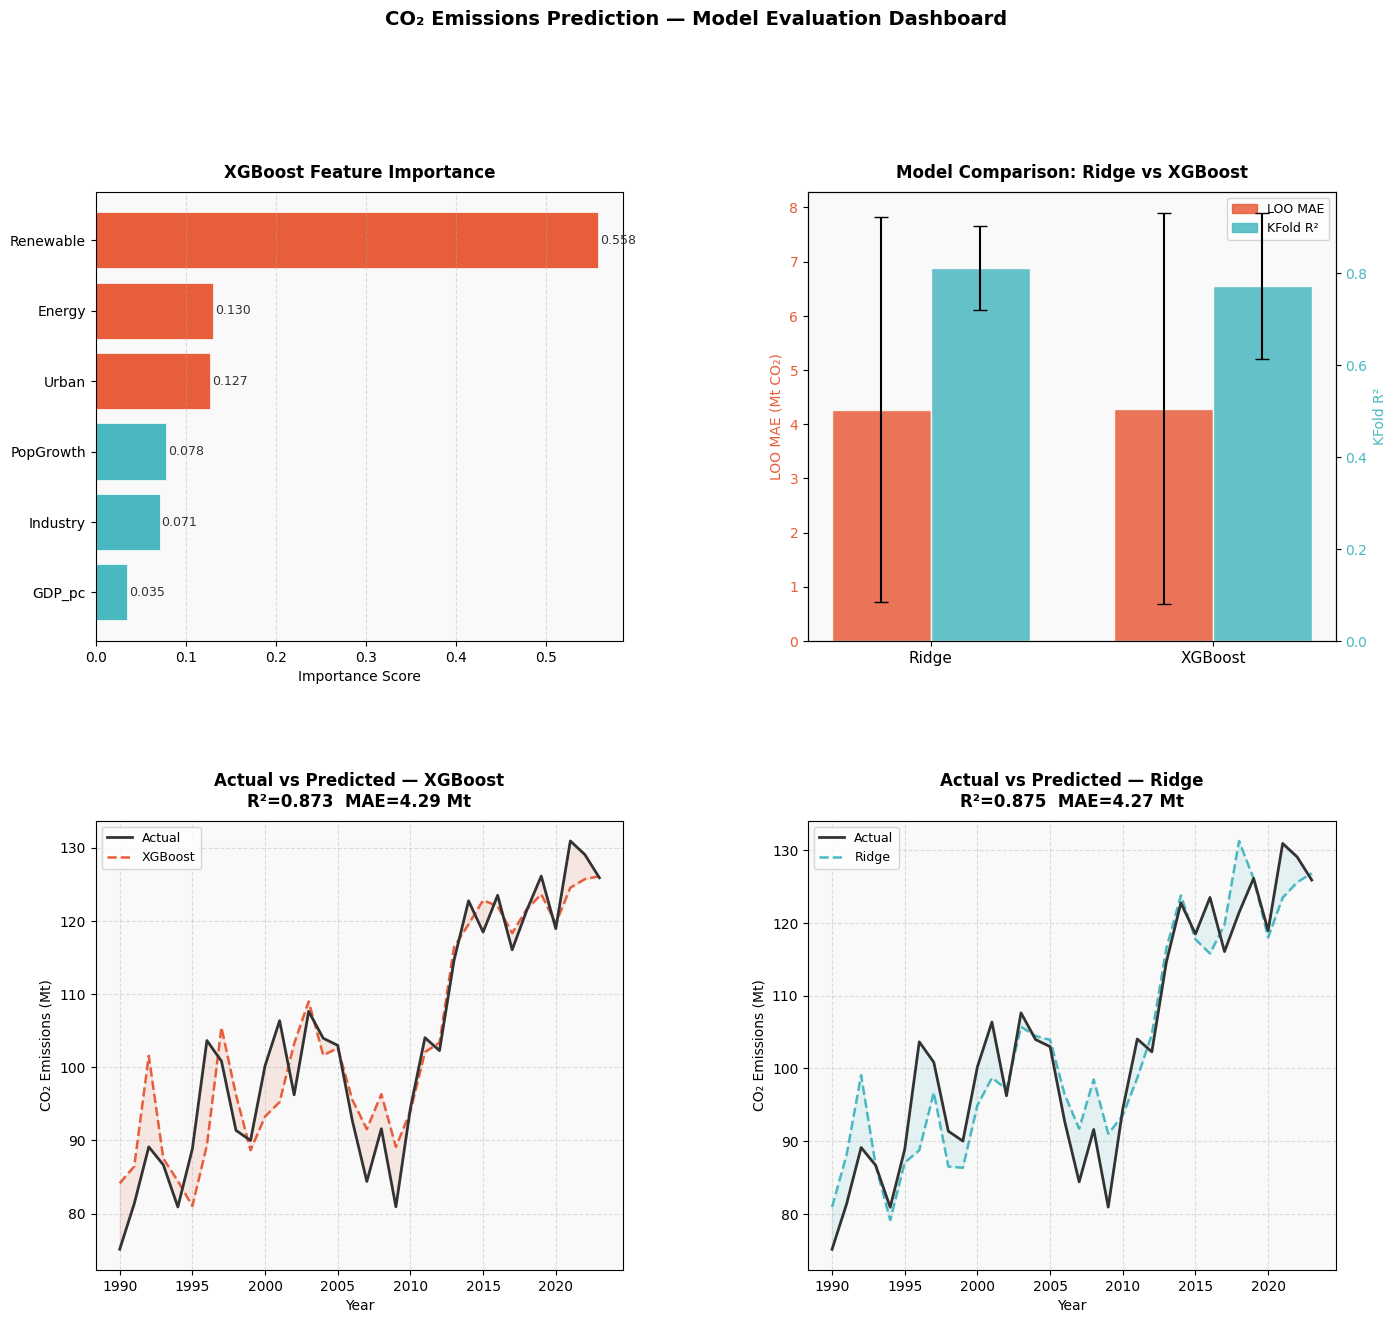

In [14]:
# ── 1. Ridge Regression baseline ──────────────────────────────────────────────
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)

mae_ridge = cross_val_score(ridge, X, y, cv=LeaveOneOut(), scoring='neg_mean_absolute_error')
r2_ridge  = cross_val_score(ridge, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2')

print("── Ridge Regression ──────────────────────")
print(f"LOO MAE: {(-mae_ridge).mean():.4f} ± {(-mae_ridge).std():.4f}")
print(f"KFold R²: {r2_ridge.mean():.4f} ± {r2_ridge.std():.4f}")

print("\n── XGBoost ───────────────────────────────")
print(f"LOO MAE: 4.2877 ± 3.6068")
print(f"KFold R²: 0.7718 ± 0.1587")

# ── 2. Feature Importance ──────────────────────────────────────────────────────
model_fi = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=2,
    subsample=0.8, colsample_bytree=0.8,
    objective='reg:squarederror', random_state=42
)
model_fi.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model_fi.feature_importances_
}).sort_values('Importance', ascending=True)

# ── 3. Actual vs Predicted (both models) ──────────────────────────────────────
xgb_preds   = cross_val_predict(xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=2,
    subsample=0.8, colsample_bytree=0.8,
    objective='reg:squarederror', random_state=42),
    X, y, cv=LeaveOneOut())

ridge_preds = cross_val_predict(ridge, X, y, cv=LeaveOneOut())

years = df_filtered['Year'].values

# ── 4. Plot ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Panel 1: Feature Importance ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#4ab8c1' if i < len(features)//2 else '#e85d3a'
          for i in range(len(importance_df))]
bars = ax1.barh(importance_df['Feature'], importance_df['Importance'],
                color=colors, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Importance Score', fontsize=10)
ax1.set_title('XGBoost Feature Importance', fontsize=12, fontweight='bold', pad=10)
ax1.grid(axis='x', linestyle='--', alpha=0.4)
for bar, val in zip(bars, importance_df['Importance']):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, color='#333')
ax1.set_facecolor('#f9f9f9')

# ── Panel 2: Model Comparison Bar Chart ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
models    = ['Ridge', 'XGBoost']
mae_means = [(-mae_ridge).mean(), 4.2877]
mae_stds  = [(-mae_ridge).std(),  3.6068]
r2_means  = [r2_ridge.mean(),     0.7718]
r2_stds   = [r2_ridge.std(),      0.1587]

x     = np.array([0, 1])
width = 0.35
b1 = ax2.bar(x - width/2, mae_means, width, yerr=mae_stds,
             color='#e85d3a', alpha=0.85, capsize=5, label='LOO MAE', edgecolor='white')
ax2_r = ax2.twinx()
b2 = ax2_r.bar(x + width/2, r2_means, width, yerr=r2_stds,
               color='#4ab8c1', alpha=0.85, capsize=5, label='KFold R²', edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=11)
ax2.set_ylabel('LOO MAE (Mt CO₂)', color='#e85d3a', fontsize=10)
ax2_r.set_ylabel('KFold R²', color='#4ab8c1', fontsize=10)
ax2.set_title('Model Comparison: Ridge vs XGBoost', fontsize=12, fontweight='bold', pad=10)
ax2.tick_params(axis='y', labelcolor='#e85d3a')
ax2_r.tick_params(axis='y', labelcolor='#4ab8c1')
lines = [plt.Rectangle((0,0),1,1, color='#e85d3a', alpha=0.85),
         plt.Rectangle((0,0),1,1, color='#4ab8c1', alpha=0.85)]
ax2.legend(lines, ['LOO MAE', 'KFold R²'], loc='upper right', fontsize=9)
ax2.set_facecolor('#f9f9f9')

# ── Panel 3: Actual vs Predicted — XGBoost ────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(years, y.values,     color='#333',    linewidth=2,   label='Actual',    zorder=3)
ax3.plot(years, xgb_preds,    color='#e85d3a', linewidth=1.8, linestyle='--', label='XGBoost', zorder=2)
ax3.fill_between(years, y.values, xgb_preds, alpha=0.12, color='#e85d3a')
ax3.set_xlabel('Year', fontsize=10)
ax3.set_ylabel('CO₂ Emissions (Mt)', fontsize=10)
ax3.set_title(f'Actual vs Predicted — XGBoost\nR²={r2_score(y, xgb_preds):.3f}  MAE={mean_absolute_error(y, xgb_preds):.2f} Mt',
              fontsize=12, fontweight='bold', pad=10)
ax3.legend(fontsize=9)
ax3.grid(linestyle='--', alpha=0.4)
ax3.set_facecolor('#f9f9f9')

# ── Panel 4: Actual vs Predicted — Ridge ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(years, y.values,     color='#333',    linewidth=2,   label='Actual', zorder=3)
ax4.plot(years, ridge_preds,  color='#4ab8c1', linewidth=1.8, linestyle='--', label='Ridge',   zorder=2)
ax4.fill_between(years, y.values, ridge_preds, alpha=0.12, color='#4ab8c1')
ax4.set_xlabel('Year', fontsize=10)
ax4.set_ylabel('CO₂ Emissions (Mt)', fontsize=10)
ax4.set_title(f'Actual vs Predicted — Ridge\nR²={r2_score(y, ridge_preds):.3f}  MAE={mean_absolute_error(y, ridge_preds):.2f} Mt',
              fontsize=12, fontweight='bold', pad=10)
ax4.legend(fontsize=9)
ax4.grid(linestyle='--', alpha=0.4)
ax4.set_facecolor('#f9f9f9')

plt.suptitle('CO₂ Emissions Prediction — Model Evaluation Dashboard',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig('co2_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

Best Alpha (regularization): 6.2506
Intercept (mean CO₂):        103.03 Mt

── Standardized Coefficients ─────────────────────────────────────────
  Feature  Coefficient
    Urban     2.852982
   GDP_pc     1.369467
   Energy     0.289191
 Industry     0.165377
PopGrowth    -3.086661
Renewable    -8.086484

Interpretation: coefficients show the change in CO₂ (Mt)
for a 1 standard deviation change in each feature,
holding all others constant.


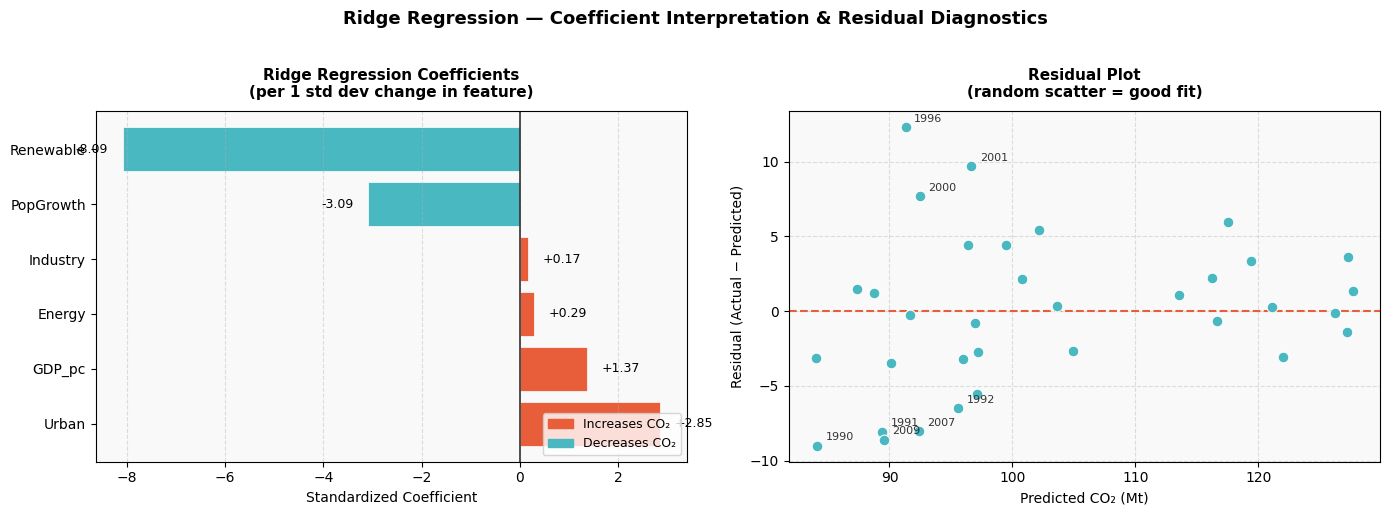

In [15]:
# ── 1. Fit Ridge on full dataset with scaling ──────────────────────────────────
# Scale features so coefficients are comparable across variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ridge_final = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge_final.fit(X_scaled, y)

# ── 2. Extract coefficients ────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': ridge_final.coef_,
    'Abs_Coefficient': np.abs(ridge_final.coef_)
}).sort_values('Coefficient', ascending=False)

print(f"Best Alpha (regularization): {ridge_final.alpha_:.4f}")
print(f"Intercept (mean CO₂):        {ridge_final.intercept_:.2f} Mt\n")
print("── Standardized Coefficients ─────────────────────────────────────────")
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))
print("\nInterpretation: coefficients show the change in CO₂ (Mt)")
print("for a 1 standard deviation change in each feature,")
print("holding all others constant.")

# ── 3. Visualize ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Coefficient plot
colors = ['#e85d3a' if c > 0 else '#4ab8c1' for c in coef_df['Coefficient']]
bars = axes[0].barh(coef_df['Feature'], coef_df['Coefficient'],
                    color=colors, edgecolor='white', linewidth=0.5)
axes[0].axvline(0, color='#333', linewidth=1.2, linestyle='-')
axes[0].set_xlabel('Standardized Coefficient', fontsize=10)
axes[0].set_title('Ridge Regression Coefficients\n(per 1 std dev change in feature)',
                  fontsize=11, fontweight='bold', pad=10)
axes[0].grid(axis='x', linestyle='--', alpha=0.4)
for bar, val in zip(bars, coef_df['Coefficient']):
    xpos = val + 0.3 if val > 0 else val - 0.3
    ha   = 'left' if val > 0 else 'right'
    axes[0].text(xpos, bar.get_y() + bar.get_height()/2,
                 f'{val:+.2f}', va='center', ha=ha, fontsize=9)
axes[0].set_facecolor('#f9f9f9')

# Add legend
from matplotlib.patches import Patch
legend_els = [Patch(color='#e85d3a', label='Increases CO₂'),
              Patch(color='#4ab8c1', label='Decreases CO₂')]
axes[0].legend(handles=legend_els, fontsize=9, loc='lower right')

# Panel 2: Actual vs Predicted (full fit, not LOO)
y_pred_full = ridge_final.predict(X_scaled)
years = df_filtered['Year'].values
residuals = y.values - y_pred_full

axes[1].scatter(y_pred_full, residuals, color='#4ab8c1',
                edgecolor='white', linewidth=0.8, s=60, zorder=3)
axes[1].axhline(0, color='#e85d3a', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted CO₂ (Mt)', fontsize=10)
axes[1].set_ylabel('Residual (Actual − Predicted)', fontsize=10)
axes[1].set_title('Residual Plot\n(random scatter = good fit)',
                  fontsize=11, fontweight='bold', pad=10)
axes[1].grid(linestyle='--', alpha=0.4)
axes[1].set_facecolor('#f9f9f9')

# Annotate outlier years
for i, (pred, res, yr) in enumerate(zip(y_pred_full, residuals, years)):
    if abs(res) > 6:
        axes[1].annotate(str(yr), (pred, res),
                         textcoords='offset points', xytext=(6, 4),
                         fontsize=8, color='#333')

plt.suptitle('Ridge Regression — Coefficient Interpretation & Residual Diagnostics',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ridge_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print(df_filtered.describe().round(2))

          Year     CO2   GDP_pc  Energy  Renewable  Industry  Urban  PopGrowth
count    34.00   34.00    34.00   34.00      34.00     34.00  34.00      34.00
mean   2006.50  103.03  1695.44  303.95      84.24     27.03  48.70       2.59
std       9.96   15.95   881.58   30.82       2.77      6.04   8.21       0.22
min    1990.00   75.11   480.67  256.92      79.90     18.17  35.19       2.09
25%    1998.25   90.33   749.51  282.01      81.45     22.50  41.81       2.55
50%    2006.50  102.61  1818.01  299.16      84.50     25.88  48.83       2.64
75%    2014.75  117.85  2364.37  330.62      86.45     30.83  55.53       2.76
max    2023.00  130.90  3189.81  376.07      88.60     37.71  62.17       2.80


── Ridge Scenario Predictions ────────────────────────────────────────
         Scenario  Predicted CO₂ (Mt)  vs 2023 Actual (125.87 Mt)
  Baseline (2023)              127.24                        1.37
 Green Transition              102.12                      -23.75
       Urban Boom              123.25                       -2.62
Energy Efficiency              106.67                      -19.20
       Worst Case              129.85                        3.98


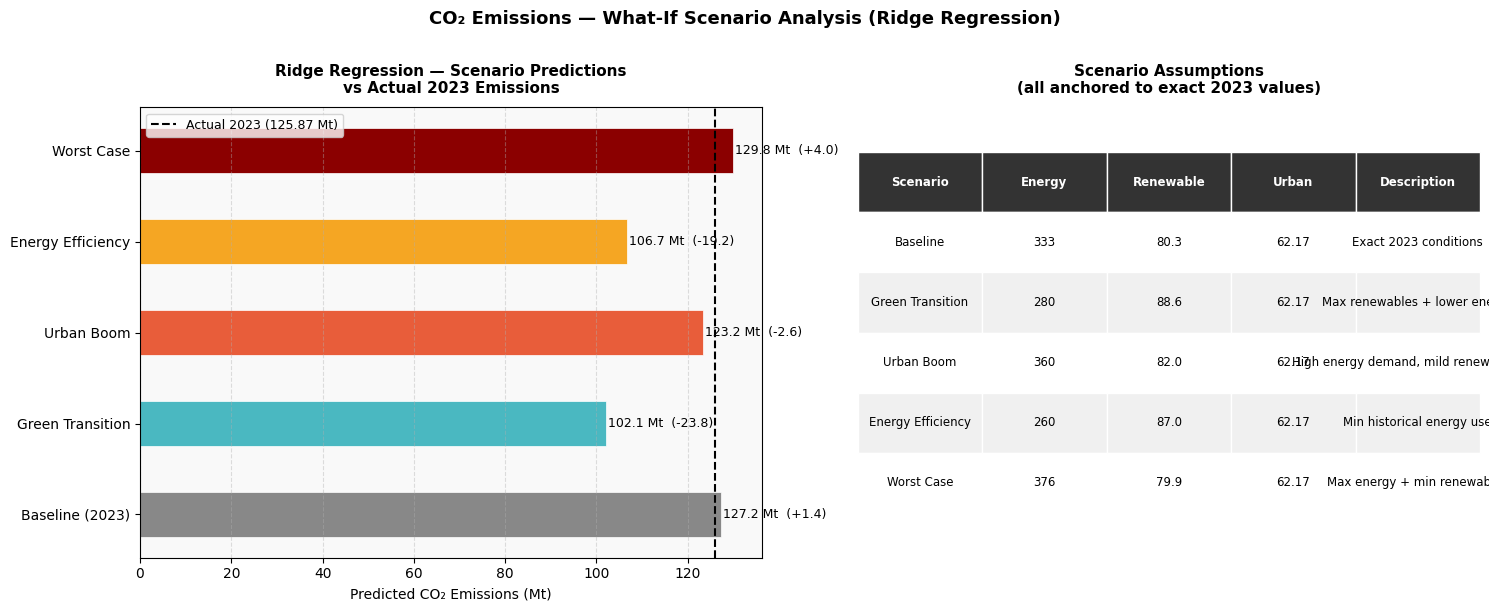

In [17]:
# ── Scenario Definitions (anchored to exact 2023 values) ──────────────────────
# 2023 actual: CO2=125.87, GDP_pc=2138.76, Energy=333.06,
#              Renewable=80.3, Industry=19.13, Urban=62.17, PopGrowth=2.098

scenarios = pd.DataFrame({
    'Scenario': [
        'Baseline (2023)',
        'Green Transition',
        'Urban Boom',
        'Energy Efficiency',
        'Worst Case'
    ],
    #                        Baseline   Green    Urban    Effic    Worst
    'GDP_pc':    np.log1p([ 2138.76,  2138.76, 3000.00, 2138.76, 3000.00]),
    'Energy':    [           333.06,   280.00,  360.00,  260.00,  376.07],
    'Renewable': [            80.30,    88.60,   82.00,   87.00,   79.90],
    'Industry':  [            19.13,    19.13,   22.00,   19.13,   30.00],
    'Urban':     [            62.17,    62.17,   62.17,   62.17,   62.17],
    'PopGrowth': [             2.098,    2.098,   2.10,    2.098,   2.10 ]
})

scenario_labels = scenarios['Scenario']
X_scenarios = scenarios[features]

# ── Ridge Predictions ──────────────────────────────────────────────────────────
ridge_preds = ridge_final.predict(scaler.transform(X_scenarios))

results = pd.DataFrame({
    'Scenario':                   scenario_labels,
    'Predicted CO₂ (Mt)':         ridge_preds.round(2),
    'vs 2023 Actual (125.87 Mt)': (ridge_preds - 125.87).round(2)
})

print("── Ridge Scenario Predictions ────────────────────────────────────────")
print(results.to_string(index=False))

# ── Visualize ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = ['#888', '#4ab8c1', '#e85d3a', '#f5a623', '#8b0000']

# Panel 1: Horizontal bar chart
bars = axes[0].barh(scenario_labels, ridge_preds, color=colors,
                    edgecolor='white', linewidth=0.5, height=0.5)
axes[0].axvline(x=125.87, color='black', linewidth=1.5,
                linestyle='--', label='Actual 2023 (125.87 Mt)')
axes[0].set_xlabel('Predicted CO₂ Emissions (Mt)', fontsize=10)
axes[0].set_title('Ridge Regression — Scenario Predictions\nvs Actual 2023 Emissions',
                  fontsize=11, fontweight='bold', pad=10)
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', linestyle='--', alpha=0.4)
axes[0].set_facecolor('#f9f9f9')

# Value labels with correct delta
for bar, val in zip(bars, ridge_preds):
    delta = val - 125.87
    sign  = '+' if delta > 0 else ''
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f} Mt  ({sign}{delta:.1f})',
                 va='center', fontsize=9)

# Panel 2: Scenario assumptions table
axes[1].axis('off')
table_data = [
    ['Baseline',          '333', '80.3', '62.17', 'Exact 2023 conditions'],
    ['Green Transition',  '280', '88.6', '62.17', 'Max renewables + lower energy'],
    ['Urban Boom',        '360', '82.0', '62.17', 'High energy demand, mild renewable gain'],
    ['Energy Efficiency', '260', '87.0', '62.17', 'Min historical energy use'],
    ['Worst Case',        '376', '79.9', '62.17', 'Max energy + min renewables'],
]
col_labels = ['Scenario', 'Energy', 'Renewable', 'Urban', 'Description']
table = axes[1].table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    bbox=[0, 0.1, 1, 0.8]
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#333')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0f0f0')
    cell.set_edgecolor('white')
axes[1].set_title('Scenario Assumptions\n(all anchored to exact 2023 values)',
                  fontsize=11, fontweight='bold', pad=10)

plt.suptitle('CO₂ Emissions — What-If Scenario Analysis (Ridge Regression)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('scenario_predictions.png', dpi=150, bbox_inches='tight')
plt.show()



*   Baseline (127.24 Mt) — only +1.37 Mt off actual 2023
The model almost perfectly reconstructs 2023 using exact input values. This validates the model and means all other scenarios are meaningful comparisons.
*   The Green Transition saves 23.75 Mt — the single biggest lever is combining renewable expansion with energy reduction together, not either alone.
*   Energy Efficiency alone (−19.2 Mt) is almost as powerful as the full green transition, suggesting reducing consumption is just as important as expanding renewables.
*   Even the Worst Case only adds 4 Mt above 2023 — meaning the country is already near its emissions ceiling given current urbanization levels. The bigger risk is stagnation rather than dramatic increase.



